In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [16]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [17]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.025677,0.476484,0.752348,-0.013766,2.363043,0
1,-0.153375,-3.372525,-2.405761,-2.544457,-1.010541,0
2,1.166819,2.478085,-1.368695,0.996758,1.657758,1
3,0.171210,0.631226,0.337512,0.811237,1.258777,1
4,-0.973981,-3.534410,-1.155439,-3.085659,-1.058577,0


In [18]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [19]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [20]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [21]:
df1 = combined_sampling(df,0.5,0.5)

D:\Temp\ipykernel_13516\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [22]:
df2 = combined_sampling(df,0.5,0.5)

D:\Temp\ipykernel_13516\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [23]:
df3 = combined_sampling(df,0.5,0.5)

D:\Temp\ipykernel_13516\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [24]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col5', 'target'], dtype='object')
Index(['col1', 'col5', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')


In [25]:
df3

,col2,col1,target
56,-0.765505,-2.851404,0
41,-0.983565,-1.189690,0
14,-4.959140,-1.903696,0
28,0.783242,1.253029,1
56,-0.765505,-2.851404,0
63,-2.143880,-1.514440,0
74,-2.765468,-3.252816,0
73,-0.128917,-4.550193,0
57,-2.380895,2.590413,1
84,-1.772229,-1.435394,0


In [26]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [27]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [28]:
from sklearn.tree import plot_tree

[Text(0.5454545454545454, 0.9166666666666666, 'x[0] <= 0.202\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.2727272727272727, 0.75, 'x[0] <= -1.436\ngini = 0.191\nsamples = 28\nvalue = [25, 3]'),
 Text(0.40909090909090906, 0.8333333333333333, 'True  '),
 Text(0.18181818181818182, 0.5833333333333334, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.36363636363636365, 0.5833333333333334, 'x[0] <= -0.566\ngini = 0.375\nsamples = 12\nvalue = [9, 3]'),
 Text(0.2727272727272727, 0.4166666666666667, 'x[0] <= -0.73\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.18181818181818182, 0.25, 'x[0] <= -1.289\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.09090909090909091, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2727272727272727, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.36363636363636365, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.45454545454545453, 0.4166666666666667, 'gini = 0.0\nsamples 

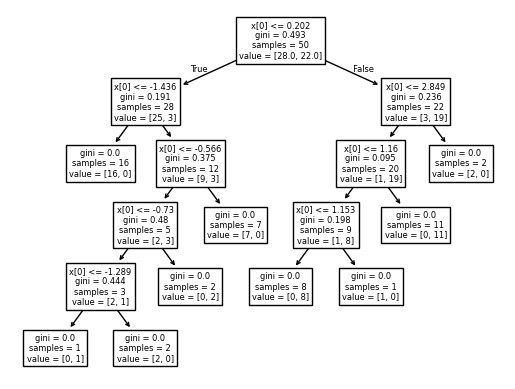

In [29]:
plot_tree(clf1)

[Text(0.5, 0.95, 'x[0] <= 0.249\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.16666666666666666, 0.85, 'x[0] <= -1.397\ngini = 0.365\nsamples = 25\nvalue = [19, 6]'),
 Text(0.3333333333333333, 0.8999999999999999, 'True  '),
 Text(0.08333333333333333, 0.75, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.25, 0.75, 'x[0] <= -1.289\ngini = 0.469\nsamples = 16\nvalue = [10, 6]'),
 Text(0.16666666666666666, 0.65, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.65, 'x[1] <= 1.871\ngini = 0.408\nsamples = 14\nvalue = [10, 4]'),
 Text(0.25, 0.55, 'x[0] <= -0.779\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.16666666666666666, 0.45, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3333333333333333, 0.45, 'x[0] <= -0.56\ngini = 0.49\nsamples = 7\nvalue = [3, 4]'),
 Text(0.25, 0.35, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4166666666666667, 0.35, 'x[0] <= -0.262\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.3333333333333333, 

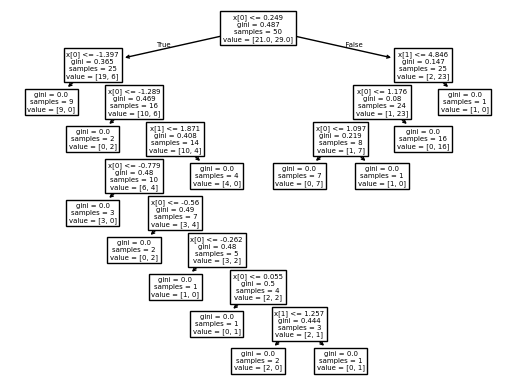

In [30]:
plot_tree(clf2)

[Text(0.4, 0.9285714285714286, 'x[1] <= -0.797\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.2, 0.7857142857142857, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.30000000000000004, 0.8571428571428572, 'True  '),
 Text(0.6, 0.7857142857142857, 'x[0] <= 0.471\ngini = 0.328\nsamples = 29\nvalue = [6, 23]'),
 Text(0.5, 0.8571428571428572, '  False'),
 Text(0.4, 0.6428571428571429, 'x[1] <= 0.547\ngini = 0.5\nsamples = 12\nvalue = [6, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6, 0.5, 'x[0] <= 0.21\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.4, 0.35714285714285715, 'x[0] <= -1.925\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.2, 0.21428571428571427, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6, 0.21428571428571427, 'x[0] <= -0.741\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.4, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.07142857142857142, 'gini = 0.0\nsamples = 3\nvalue =

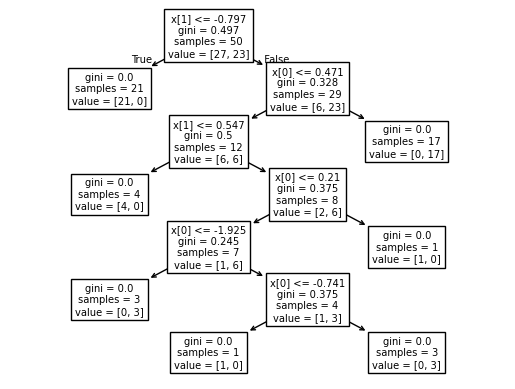

In [31]:
plot_tree(clf3)

In [32]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [33]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [34]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [35]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
76,0.262948,4.241726,0.191550,2.321746,2.987460,1
49,1.717757,2.507774,-0.759763,4.165894,4.196027,1
71,2.210208,-0.398357,-1.772113,1.368957,-0.121592,1
13,0.677351,-0.137041,-2.802867,0.193395,-0.742603,1
66,1.153126,-1.334103,-1.710267,-2.566512,0.233003,0
63,-1.514440,-2.143880,-1.842911,-1.076873,-1.206779,0
29,0.829401,0.340630,-2.173841,0.320226,0.051866,0
70,2.192368,-0.486757,-0.780688,-2.012131,-3.015402,1
81,-1.233517,0.499093,0.065212,-0.240345,3.804350,0
6,0.061209,2.182059,-0.439533,2.701081,3.482606,1
